In [34]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from nltk.corpus import stopwords
import re
import string
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk
from langdetect import detect

iso_to_nltk = {
    'en': 'english',
    'es': 'spanish',
    'pl': 'polish',
    'fr': 'french',
    'de': 'german',
    'it': 'italian',
    'pt': 'portuguese',
    'ru': 'russian'
}

def get_language(text):
    try:
        return detect(text)
    except:
        #w razie problemu zwracamy unknow
        return 'unknown'

# 1. Do dzielenia tekstu na słowa (word_tokenize)
nltk.download('punkt_tab',quiet=True)
# 2. Do filtrowania nieistotnych słów (stopwords)
nltk.download('stopwords',quiet=True)
# 3. Do sprowadzania słów do formy podstawowej (lemmatizer)
nltk.download('wordnet',quiet=True)

lemmatizer = WordNetLemmatizer()

excel_path = "../zadanie3/MED-lab-3-Zad 3-Mandrill-Dane.xlsx"
excel = pd.ExcelFile(excel_path)

mandrill_dane = pd.read_excel(excel, sheet_name="dot. aplikacji Mandrill")
inne_dane = pd.read_excel(excel, sheet_name="dot. innych")

mandrill_dane['label'] = "Mandrill"
inne_dane['label'] = "Inne"

X = pd.concat([mandrill_dane, inne_dane])
X['jezyk'] = X['Post'].apply(get_language)

def clean_text(text, lang_code):
    #domyslnie angielski
    nltk_lang = iso_to_nltk.get(lang_code, 'english')
    stop_words = set(stopwords.words(nltk_lang))
    #czyszczenie
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    #tokenizacja
    words = word_tokenize(text)
    #lematyzacja
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(cleaned_words)

X['czysty'] = X.apply(lambda row: clean_text(str(row['Post']), row['jezyk']), axis=1)
Y = X['label']
X = X.drop(['Post', 'label'], axis=1)



D:\studia\studia\studia 3.1\MED\seweryn\zajecia3\Lab3\zadanie1\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
D:\studia\studia\studia 3.1\MED\seweryn\zajecia3\Lab3\zadanie1\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [35]:
vectorizer = CountVectorizer()
X_vec = vectorizer.fit_transform(X['czysty'])

feature_names = vectorizer.get_feature_names_out()

print(f"Liczba wszystkich słów w słowniku: {len(feature_names)}")
print(f"Przykładowe słowa (co 500-tne): {feature_names[::100]}")
X_train, X_test, y_train, y_test = train_test_split(X_vec, Y, test_size=0.3, random_state=42)

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Liczba wszystkich słów w słowniku: 1255
Przykładowe słowa (co 500-tne): ['003' 'aufn' 'classic' 'domecq' 'fleet' 'hispanic' 'less' 'million'
 'people' 'recommended' 'soo' 'top' 'winamp']

Accuracy: 0.9222

Classification Report:
              precision    recall  f1-score   support

        Inne       0.87      0.98      0.92        42
    Mandrill       0.98      0.88      0.92        48

    accuracy                           0.92        90
   macro avg       0.92      0.93      0.92        90
weighted avg       0.93      0.92      0.92        90



<Figure size 1000x600 with 0 Axes>

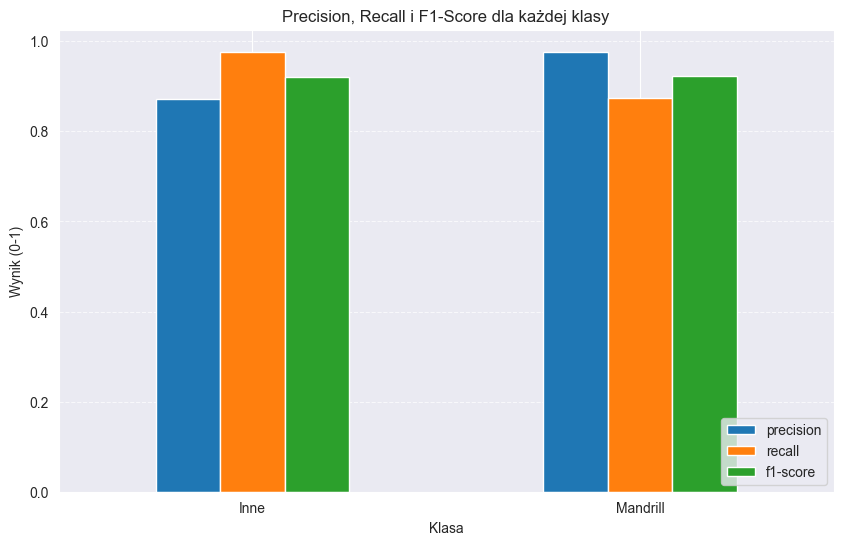

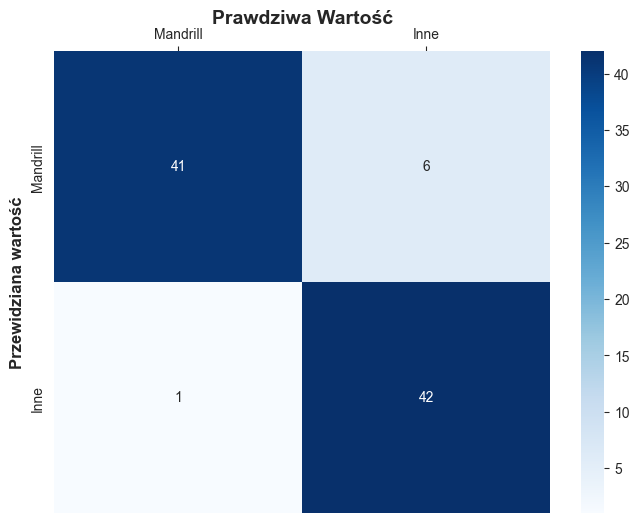

In [36]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
classes_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'])

plt.figure(figsize=(10, 6))
classes_df[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(10, 6))
plt.title('Precision, Recall i F1-Score dla każdej klasy')
plt.ylabel('Wynik (0-1)')
plt.xlabel('Klasa')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
plt.figure(figsize=(8, 6))

my_labels = ['Inne', 'Mandrill']

cm = confusion_matrix(y_test, y_pred, labels=my_labels)
cm_structure = cm.T

labels = ['Mandrill', 'Inne']

sns.heatmap(cm_structure, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.gca().xaxis.tick_top()
plt.gca().xaxis.set_label_position('top')

plt.title('Prawdziwa Wartość', pad=20, fontsize=14, fontweight='bold')
plt.ylabel('Przewidziana wartość', fontsize=12, fontweight='bold')
plt.xlabel('')

plt.show()

In [37]:
import pandas as pd
import numpy as np
from IPython.display import display

def analiza_z_liczbami(model, vectorizer, x_vec, y_true, index=0):
    sample_vector = x_vec[index]
    true_label = y_true.iloc[index]
    feature_names = vectorizer.get_feature_names_out()

    word_indices = sample_vector.nonzero()[1]
    present_words = [feature_names[i] for i in word_indices]
    word_counts_in_doc = [sample_vector[0, i] for i in word_indices]

    classes = model.classes_
    alpha = model.alpha
    n_features = len(feature_names)

    print(f"--- ANALIZA POSTA (Indeks: {index}) ---")
    print(f"Treść (słowa kluczowe): \"{' '.join(present_words)}\"")
    print(f"Prawdziwa klasa: {true_label}\n")
    print("1. BAZA WIEDZY MODELU (Statystyki ze zbioru treningowego):")
    print(f"   Całkowita liczba słów w słowniku (V): {n_features}")
    print(f"   Parametr wygładzania Laplace'a (Alpha): {alpha}")

    stats_data = []
    for class_idx, class_name in enumerate(classes):
        doc_count = model.class_count_[class_idx] # Ile dokumentów w klasie
        total_words = np.sum(model.feature_count_[class_idx]) # Ile wszystkich słów w klasie

        stats_data.append({
            "Klasa": class_name,
            "Liczba wystąpień": int(doc_count),
            "Suma wszystkich słów": int(total_words),
            "Prawdopodobieństwo a priori": f"{np.exp(model.class_log_prior_[class_idx]):.4f}"
        })

    df_stats = pd.DataFrame(stats_data).set_index("Klasa")
    display(df_stats)
    print("\n")

    print("2. SZCZEGÓŁOWE LICZNIKI SŁÓW:")
    print("   Tabela pokazuje, ile razy dane słowo wystąpiło w zbiorze treningowym dla każdej klasy.")

    word_stats = []
    for i, word_idx in enumerate(word_indices):
        word = present_words[i]
        row = {"Słowo": word}
        for class_idx, class_name in enumerate(classes):
            count_in_class = model.feature_count_[class_idx, word_idx]
            row[f"Wystąpienia w '{class_name}'"] = int(count_in_class)
        word_stats.append(row)

    df_words = pd.DataFrame(word_stats).set_index("Słowo")
    display(df_words)
    print("\n")

    print("3. PODSTAWIENIE DO WZORU (Wygładzanie Laplace'a):")
    print("   P(Słowo|Klasa) = (Wystąpienia_słowa + Alpha) / (Suma_słów_klasy + Alpha * V)")
    print("-" * 70)

    scores = {}
    for class_idx, class_name in enumerate(classes):
        print(f"\nKLASA: '{class_name}'")

        # Mianownik jest stały dla całej klasy: Wszystkie słowa w klasie + (Alpha * Słownik)
        total_words_in_class = np.sum(model.feature_count_[class_idx])
        denominator = total_words_in_class + (alpha * n_features)

        log_prior = model.class_log_prior_[class_idx]
        current_score = log_prior

        print(f"  Log P(a priori) = {log_prior:.4f}")

        for i, word_idx in enumerate(word_indices):
            word = present_words[i]
            count_in_doc = word_counts_in_doc[i]
            count_in_class = model.feature_count_[class_idx, word_idx]

            # Obliczenie prawdopodobieństwa
            numerator = count_in_class + alpha
            prob = numerator / denominator
            log_prob = np.log(prob)

            term = count_in_doc * log_prob
            current_score += term

            print(f"  + Słowo '{word}':")
            print(f"      Licznik: {int(count_in_class)} + {alpha} = {numerator}")
            print(f"      Mianownik: {int(total_words_in_class)} + ({alpha} * {n_features}) = {denominator}")
            print(f"      P({word}|{class_name}) = {numerator} / {denominator} ≈ {prob:.6f}")
            print(f"      Logarytm: {log_prob:.4f}")

        print(f"  = SUMA (SCORE): {current_score:.4f}")
        scores[class_name] = current_score

    winner = max(scores, key=scores.get)
    print("-" * 70)
    print(f"WERDYKT MODELU: {winner}")

analiza_z_liczbami(model, vectorizer, X_test, y_test, index=25)

--- ANALIZA POSTA (Indeks: 25) ---
Treść (słowa kluczowe): "mandrill mail service use like ee"
Prawdziwa klasa: Mandrill

1. BAZA WIEDZY MODELU (Statystyki ze zbioru treningowego):
   Całkowita liczba słów w słowniku (V): 1255
   Parametr wygładzania Laplace'a (Alpha): 1.0


,Liczba wystąpień,Suma wszystkich słów,Prawdopodobieństwo a priori
Klasa,,,
Inne,108,755,0.5143
Mandrill,102,850,0.4857




2. SZCZEGÓŁOWE LICZNIKI SŁÓW:
   Tabela pokazuje, ile razy dane słowo wystąpiło w zbiorze treningowym dla każdej klasy.


,Wystąpienia w 'Inne',Wystąpienia w 'Mandrill'
Słowo,,
mandrill,72,67
mail,0,3
service,1,11
use,0,8
like,5,2
ee,0,0




3. PODSTAWIENIE DO WZORU (Wygładzanie Laplace'a):
   P(Słowo|Klasa) = (Wystąpienia_słowa + Alpha) / (Suma_słów_klasy + Alpha * V)
----------------------------------------------------------------------

KLASA: 'Inne'
  Log P(a priori) = -0.6650
  + Słowo 'mandrill':
      Licznik: 72 + 1.0 = 73.0
      Mianownik: 755 + (1.0 * 1255) = 2010.0
      P(mandrill|Inne) = 73.0 / 2010.0 ≈ 0.036318
      Logarytm: -3.3154
  + Słowo 'mail':
      Licznik: 0 + 1.0 = 1.0
      Mianownik: 755 + (1.0 * 1255) = 2010.0
      P(mail|Inne) = 1.0 / 2010.0 ≈ 0.000498
      Logarytm: -7.6059
  + Słowo 'service':
      Licznik: 1 + 1.0 = 2.0
      Mianownik: 755 + (1.0 * 1255) = 2010.0
      P(service|Inne) = 2.0 / 2010.0 ≈ 0.000995
      Logarytm: -6.9127
  + Słowo 'use':
      Licznik: 0 + 1.0 = 1.0
      Mianownik: 755 + (1.0 * 1255) = 2010.0
      P(use|Inne) = 1.0 / 2010.0 ≈ 0.000498
      Logarytm: -7.6059
  + Słowo 'like':
      Licznik: 5 + 1.0 = 6.0
      Mianownik: 755 + (1.0 * 1255) = 2010.0
   